<a href="https://colab.research.google.com/github/kanchanbiswas058/OIBSIP/blob/main/Sales%20Prediction%20Using%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Sales Prediction Using Python***

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_style("whitegrid")

**Load Dataset**

In [ ]:
url = "https://gist.githubusercontent.com/rparrapy/bc7804cada859938d433c25ec2a3f00c/raw/Advertising.csv"
df = pd.read_csv(url)

print(df.head())
print("Shape:", df.shape)

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
Shape: (200, 5)


**Exploratory Data Analysis**


Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Descriptive Statistics:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


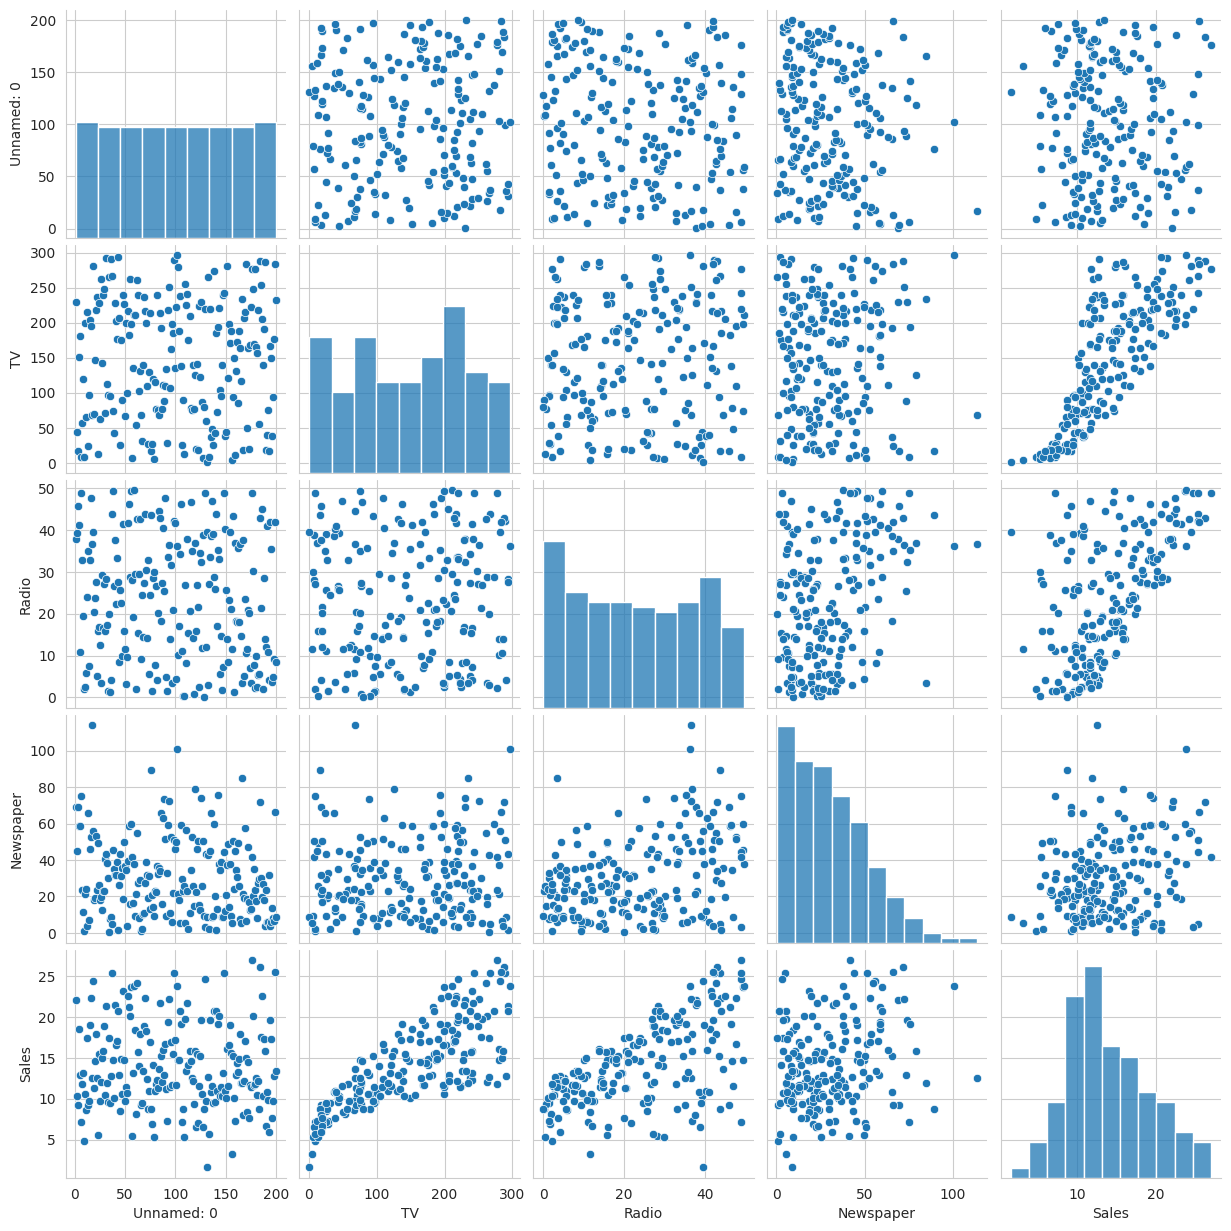

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

# Pairplot
sns.pairplot(df)
plt.show()


**Individual Scatter Plots**

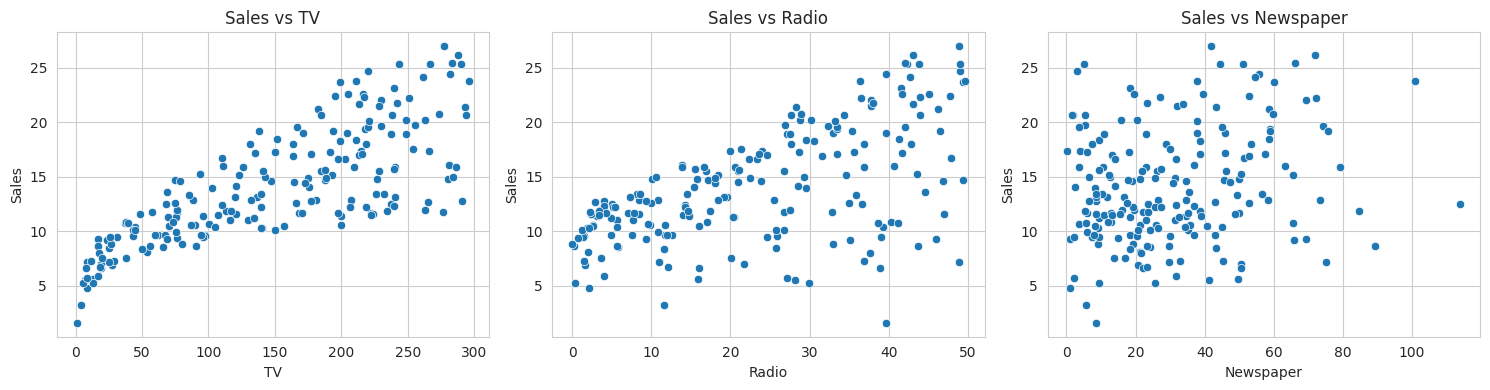

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0])
axes[0].set_title("Sales vs TV")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1])
axes[1].set_title("Sales vs Radio")

sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2])
axes[2].set_title("Sales vs Newspaper")

plt.tight_layout()
plt.show()


**Correlation Heatmap**

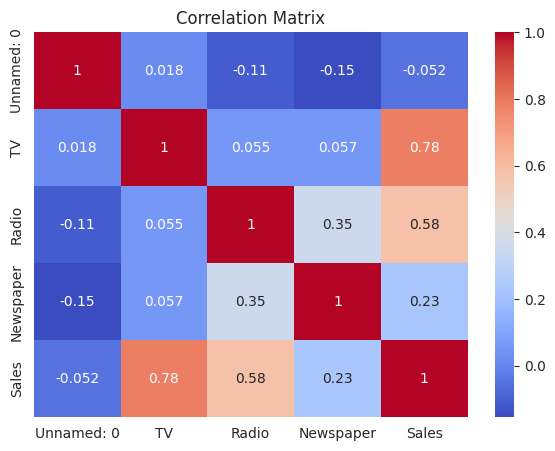

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Train/Test Split**

In [ ]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Linear Regression**

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

**Random Forest**

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

**Evaluation Function**

In [ ]:
def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²  :", round(r2, 3))

    return mae, rmse, r2


lr_scores = evaluate("Linear Regression", y_test, pred_lr)
rf_scores = evaluate("Random Forest", y_test, pred_rf)


Linear Regression
MAE : 1.461
RMSE: 1.782
R²  : 0.899

Random Forest
MAE : 0.629
RMSE: 0.757
R²  : 0.982


**Select Best Model**

In [ ]:
if rf_scores[2] > lr_scores[2]:
    best_pred = pred_rf
    best_name = "Random Forest"
else:
    best_pred = pred_lr
    best_name = "Linear Regression"

print("\nBest Model:", best_name)


Best Model: Random Forest


**Residual Plot**

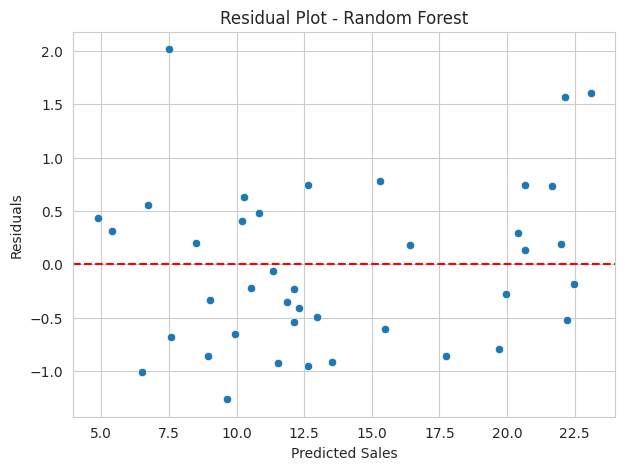

In [ ]:
residuals = y_test - best_pred

plt.figure(figsize=(7, 5))
sns.scatterplot(x=best_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_name}")
plt.show()

**Feature Impact**


Linear Regression Coefficients:
TV : 0.0447
Radio : 0.1892
Newspaper : 0.0028

Random Forest Feature Importance:
TV           0.624727
Radio        0.362119
Newspaper    0.013153
dtype: float64


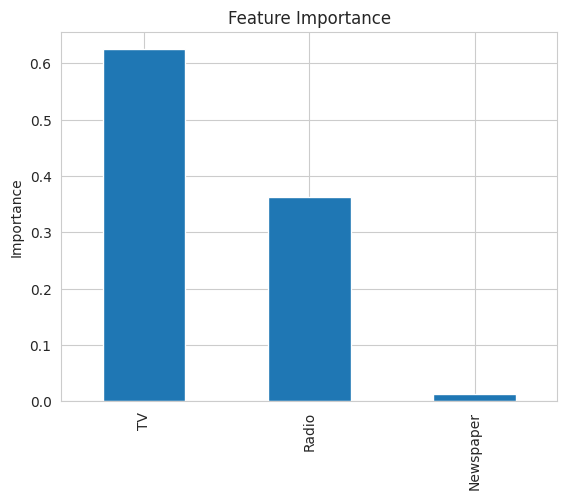

In [ ]:
print("\nLinear Regression Coefficients:")
for feature, coef in zip(X.columns, lr.coef_):
    print(feature, ":", round(coef, 4))

print("\nRandom Forest Feature Importance:")
importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar", title="Feature Importance")
plt.ylabel("Importance")
plt.show()

**Conclusion**

The analysis shows that TV advertising generally has the highest impact on sales, followed by Radio, while Newspaper has the weakest contribution among the three channels. The exact ranking should be confirmed from the coefficients and feature-importance values produced by your train/test split.